---
authors:
  - name: Juniper Tyree
    orcid: 0000-0002-7923-9609
    affiliations:
      - name: University of Helsinki
        ror: 040af2s02
    github: juntyr
  - name: Martin Burtscher
    orcid: 0000-0001-7717-3354
    affiliations:
      - name: ETH Zurich
        ror: 05h9q1g27
    github: burtscher
---

# LC

| [![version-badge]][version-url] | [![citation-badge]][citation-url] | [![source-badge]][source-url] | [![pitch-badge]][pitch-url] |
|:-:|:-:|:-:|:-:|

[version-badge]: https://img.shields.io/badge/v2025+-grey?style=for-the-badge
[citation-badge]: https://img.shields.io/badge/citation-grey?style=for-the-badge&logo=doi&logoColor=white
[source-badge]: https://img.shields.io/badge/source-grey?style=for-the-badge&logo=github&logoColor=white
[pitch-badge]: https://img.shields.io/badge/pitch-grey?style=for-the-badge&logo=slides&logoColor=white

[version-url]: https://github.com/juntyr/LC-framework/tree/03008848201c3e6067809dafe03e028e6233e360
[citation-url]: https://doi.org/10.48550/arxiv.2407.15037
[source-url]: https://github.com/burtscher/LC-framework
[pitch-url]: https://github.com/climet-eu/egu26-compression-sc2-5/blob/1.0.0/pitches/e-lc.pdf

LC [^lc] is a framework for constructing modular lossless and lossy compressors from a collection of preprocessors and components. LC provides cross-platform compression that is guaranteed to produce the same results on CPUs and GPUs. LC supports pointwise absolute, relative, and normalised error bounds using quantisation-based preprocessors.

LC's native implementation [^lcgh] also provides tools to find optimal compression pipelines using exhaustive search and genetic algorithms.

The implementation in `numcodecs-wasm-lc` provides a compressor that can be configured with the preprocessor and components that it should consist of.

[^lc]: Fallin, A., & Burtscher, M. (2024). Lessons learned on the path to guaranteeing the error bound in lossy quantizers. *arXiv*. Available from: [doi:10.48550/arxiv.2407.15037](https://doi.org/10.48550/arxiv.2407.15037).

[^lcgh]: <https://github.com/burtscher/LC-framework>

In [1]:
import sys

sys.path.insert(0, "..")

In [2]:
import h5netcdf
import numpy as np
import xarray as xr
from upath import UPath

[pyodide]: Loading fsspec, h5netcdf, numpy, pandas, pathlib_abc, python-dateutil, pytz, six, tzdata, universal_pathlib, xarray
[pyodide]: Loaded fsspec, h5netcdf, numpy, pandas, pathlib_abc, python-dateutil, pytz, six, tzdata, universal_pathlib, xarray
[pyodide]: Loading h5py
[pyodide]: Loaded h5py
[pyodide]: Loading pyfive, typing_extensions
[pyodide]: Loaded pyfive, typing_extensions
[pyodide]: Loading pyarrow, pyodide-unix-timezones
[pyodide]: Loaded pyarrow, pyodide-unix-timezones
[pyodide]: Loading cloudpickle
[pyodide]: Loaded cloudpickle
[pyodide]: Loading Bottleneck
[pyodide]: Loaded Bottleneck
[pyodide]: Loading cftime
[pyodide]: Loaded cftime
[pyodide]: Loading PyYAML, click, dask, locket, partd, toolz
[pyodide]: Loaded PyYAML, click, dask, locket, partd, toolz
[pyodide]: Loading lz4
[pyodide]: Loaded lz4
[pyodide]: Memory usage has grown to 107.9MiB (from 43.2MiB) for this notebook
[pyodide]: Loaded 90 new dynamic libraries (93 total for this notebook)


In [3]:
# URL of S3 bucket
BASE_URL = "https://object-store.os-api.cci1.ecmwf.int/esiwacebucket"

data = UPath(BASE_URL)

In [4]:
import earthkit.plots

from utils import open_remote_dataset, quickplot

[pyodide]: Loading Cartopy, Jinja2, Markdown, MarkupSafe, Pint, adjustText, array-api-compat, attrs, cffi, cfgrib, contourpy, cycler, deprecation, earthkit-data, earthkit-plots, earthkit-utils, eccodes, eccodeslib, eckit, eckitlib, entrypoints, filelock, findlibs, flexcache, flexparser, fonttools, jsonschema, jsonschema-specifications, kiwisolver, lru-dict, matplotlib, multiurl, narwhals, netCDF4, pdbufr, pillow, platformdirs, plotly, pycparser, pyparsing, pyproj, pyshp, referencing, rpds-py, scipy, shapely, tqdm
[pyodide]: Loaded Cartopy, Jinja2, Markdown, MarkupSafe, Pint, adjustText, array-api-compat, attrs, cffi, cfgrib, contourpy, cycler, deprecation, earthkit-data, earthkit-plots, earthkit-utils, eccodes, eccodeslib, eckit, eckitlib, entrypoints, filelock, findlibs, flexcache, flexparser, fonttools, jsonschema, jsonschema-specifications, kiwisolver, lru-dict, matplotlib, multiurl, narwhals, netCDF4, pdbufr, pillow, platformdirs, plotly, pycparser, pyparsing, pyproj, pyshp, refere

## Importing the `Lc` compressor

In [5]:
from numcodecs_wasm_lc import Lc

[pyodide]: Loading Deprecated, leb128, numcodecs, numcodecs-combinators, numcodecs-observers, numcodecs_wasm, numcodecs_wasm_lc, wrapt
[pyodide]: Loaded Deprecated, leb128, numcodecs, numcodecs-combinators, numcodecs-observers, numcodecs_wasm, numcodecs_wasm_lc, wrapt
[pyodide]: Loading crc32c
[pyodide]: Loaded crc32c
[pyodide]: Loading msgpack
[pyodide]: Loaded msgpack
[pyodide]: Memory usage has grown to 155.4MiB (from 129.5MiB) for this notebook
[pyodide]: Loaded 12 new dynamic libraries (112 total for this notebook)


In [6]:
?Lc

Init signature: Lc(components, _version='0.1.0', preprocessors=[])
Docstring:     
Codec providing compression using LC

Parameters
----------
components : ...
    LC components
_version : ..., optional, default = "0.1.0"
    The codec's encoding format version. Do not provide this parameter explicitly.
preprocessors : ..., optional, default = []
    LC preprocessors
File:           /lib/python3.14/site-packages/numcodecs_wasm_lc/__init__.py
Type:           ABCMeta
Subclasses:     


### Available Preprocessors

- `NUL`: no-op, `{"id": "NUL"}`
- `LOR`: 1D Lorenzo predictor over 32 bit signed integers, e.g. `{"id": "LOR", "dtype": "i32"}`
- `QUANT`: lossy absolute (`ABS`) / relative (`REL`) / normalised-absolute (`NOA`, also known as range-relative) error-bounded quantisation for 32/64 bit floating point values with zero (`0`) or random (`R`) decorrelation, e.g. `{"id": "QUANT", "dtype": "f64", "kind": "ABS", "error_bound": 0.1, "decorrelation": "R"}`

The complete list of supported preprocessors can be inspected by providing an invalid id:

In [7]:
try:
    Lc(preprocessors=[{"id": "???"}])
except Exception as err:  # noqa: BLE001
    print(err)


 1 | {"preprocessors":[{"id":"???"}]}
   |                              ^ unknown variant `???`, expected one of `NUL`, `LOR`, `QUANT` at line 1 column 29



### Available Components [^components][^efficient]

- `NUL`: no-op, `{"id": "NUL"}`
- Mutators:
    - `TCMS`: convert from integer two's complement to sign-magnitude representation for 1/2/4/8-byte values, e.g. `{"id": "TCMS", "size": 1}`
    - `TCNB`: convert from integer two's complement to negabinary representation for 1/2/4/8-byte values, e.g. `{"id": "TCNB", "size": 2}`
    - `DBEFS`: convert from IEEE 754 floating point to debiased exponent fraction sign representation for 4/8-byte values, e.g. `{"id": "DBEFS", "size": 4}`
    - `DBESF`: convert from IEEE 754 floating point to debiased exponent sign fraction representation for 4/8-byte values, e.g. `{"id": "DBESF", "size": 8}`
- Shufflers:
    - `BIT`: bit shuffle for 1/2/4/8-byte values, e.g. `{"id": "BIT", "size": 1}`
    - `TUPL`: tuple shuffle for 2/3/4/6/8/12-element tuples of 1/2/4/8-byte values, e.g. `{"id": "TUPL", "size": "12_1"}`
- Predictors:
    - `DIFF`: delta for 1/2/4/8-byte values, e.g. `{"id": "DIFF", "size": 2}`
    - `DIFFMS`: delta as sign-magnitude for 1/2/4/8-byte values, e.g. `{"id": "DIFFMS", "size": 4}`
    - `DIFFNB`: delta as negabinary for 1/2/4/8-byte values, e.g. `{"id": "DIFFNB", "size": 8}`
- Reducers:
    - `CLOG`: chunked leading-zero-bit elimination for 1/2/4/8-byte values, e.g. `{"id": "CLOG", "size": 1}`
    - `HCLOG`: hybrid chunked leading-zero-bit elimination for 1/2/4/8-byte values, e.g. `{"id": "HCLOG", "size": 2}`
    - `RARE`: repeated adaptive redundancy elimination for 1/2/4/8-byte values, e.g. `{"id": "RARE", "size": 4}`
    - `RAZE`: repeated adaptive zero elimination for 1/2/4/8-byte values, e.g. `{"id": "RAZE", "size": 8}`
    - `RLE`: run-length encoding for 1/2/4/8-byte values, e.g. `{"id": "RLE", "size": 1}`
    - `RRE`: repeated redundancy elimination for 1/2/4/8-byte values, e.g. `{"id": "RRE", "size": 2}`
    - `RZE`: repeated zero elimination for 1/2/4/8-byte values, e.g. `{"id": "RZE", "size": 4}`

The complete list of supported components can be inspected by providing an invalid id:

[^components]: Azami, N. & Burtscher, M. (2025). Identifying Important Data Transformations for Synthesizing Effective Lossless Compressors. *2025 IEEE International Symposium on Performance Analysis of Systems and Software (ISPASS)*, 286–296. Available from: [doi:10.1109/ispass64960.2025.00034](https://doi.org/10.1109/ispass64960.2025.00034) and <https://userweb.cs.txstate.edu/~burtscher/papers/ispass25.pdf>.

[^efficient]: Azami, N., Fallin, A., & Burtscher, M. (2025). Efficient Lossless Compression of Scientific Floating-Point Data on CPUs and GPUs. *ASPLOS '25: Proceedings of the 30th ACM International Conference on Architectural Support for Programming Languages and Operating Systems*, 1, 395–409. Available from: [doi:10.1145/3669940.3707280](https://doi.org/10.1145/3669940.3707280) and <https://userweb.cs.txstate.edu/~burtscher/papers/asplos25.pdf>.

In [8]:
try:
    Lc(components=[{"id": "???"}])
except Exception as err:  # noqa: BLE001
    print(err)


 1 | {"components":[{"id":"???"}]}
   |                           ^ unknown variant `???`, expected one of `NUL`, `TCMS`, `TCNB`, `DBEFS`, `DBESF`, `BIT`, `TUPL`, `DIFF`, `DIFFMS`, `DIFFNB`, `CLOG`, `HCLOG`, `RARE`, `RAZE`, `RLE`, `RRE`, `RZE` at line 1 column 26



## Bounding the pointwise absolute error

LC can bound the absolute error using the `ABS` kind of the `QUANT` preprocessor:

In [9]:
eb_abs = 1.0

Lc(
    preprocessors=[
        {
            "id": "QUANT",
            "dtype": "f64",
            "kind": "ABS",
            "error_bound": eb_abs,
            "decorrelation": "0",
        }
    ],
    components=[
        # e.g. bit shuffle and run-length encoding over 8 byte floating point
        {"id": "BIT", "size": 8},
        {"id": "RLE", "size": 8},
    ],
)

Lc(preprocessors=[{'id': 'QUANT', 'dtype': 'f64', 'kind': 'ABS', 'error_bound': 1.0, 'threshold': None, 'decorrelation': '0'}], components=[{'id': 'BIT', 'size': 8}, {'id': 'RLE', 'size': 8}], _version='0.1.0')

## Bounding the range-relative error

LC can bound the range-relative error using the `NOA` kind of the `QUANT` preprocessor:

In [10]:
eb_range_rel = 0.01  # 1% of max(data) - min(data)

Lc(
    preprocessors=[
        {
            "id": "QUANT",
            "dtype": "f64",
            "kind": "NOA",
            "error_bound": eb_range_rel,
            "decorrelation": "0",
        }
    ],
    components=[
        # e.g. bit shuffle and run-length encoding over 8 byte floating point
        {"id": "BIT", "size": 8},
        {"id": "RLE", "size": 8},
    ],
)

Lc(preprocessors=[{'id': 'QUANT', 'dtype': 'f64', 'kind': 'NOA', 'error_bound': 0.01, 'threshold': None, 'decorrelation': '0'}], components=[{'id': 'BIT', 'size': 8}, {'id': 'RLE', 'size': 8}], _version='0.1.0')

## Bounding the pointwise relative error

LC can bound the relative error using the `REL` kind of the `QUANT` preprocessor:

In [11]:
eb_rel = 0.01

Lc(
    preprocessors=[
        {
            "id": "QUANT",
            "dtype": "f64",
            "kind": "REL",
            "error_bound": eb_rel,
            "decorrelation": "0",
        }
    ],
    components=[
        # e.g. bit shuffle and run-length encoding over 8 byte floating point
        {"id": "BIT", "size": 8},
        {"id": "RLE", "size": 8},
    ],
)

Lc(preprocessors=[{'id': 'QUANT', 'dtype': 'f64', 'kind': 'REL', 'error_bound': 0.01, 'threshold': None, 'decorrelation': '0'}], components=[{'id': 'BIT', 'size': 8}, {'id': 'RLE', 'size': 8}], _version='0.1.0')

## Preserving Missing Values

NaN values and infinities are automatically preserved by LC.

## Example

In [12]:
# Load the data
ds = open_remote_dataset(
    data / "hplp" / "hplp_sfc_regridded_t_025deg_levels_steps_204_216_228_240.nc",
    engine="h5netcdf",
    decode_timedelta=True,
)
da = ds["2t"]

[pyodide]: Loading ipyfilite, ipywidgets, jupyterlab_widgets
[pyodide]: Loaded ipyfilite, ipywidgets, jupyterlab_widgets
[pyodide]: Loading WebOb, beautifulsoup4, cattrs, legacy-cgi, lxml, pydap, requests-cache, soupsieve, url-normalize
[pyodide]: Loaded WebOb, beautifulsoup4, cattrs, legacy-cgi, lxml, pydap, requests-cache, soupsieve, url-normalize
[pyodide]: Loading donfig, google-crc32c, zarr
[pyodide]: Loaded donfig, google-crc32c, zarr
[pyodide]: Loading arraypartition, cfapyx
[pyodide]: Loaded arraypartition, cfapyx


/lib/python3.14/site-packages/earthkit/data/core/config.py:287: UserWarning: only soft file lock is available
  from filelock import FileLock


[pyodide]: Loading MetPy, pooch
[pyodide]: Loaded MetPy, pooch
[pyodide]: Loading uncertainties
[pyodide]: Loaded uncertainties
[pyodide]: Loading click-plugins, cligj, fiona
[pyodide]: Loaded click-plugins, cligj, fiona
[pyodide]: Loading boto3, botocore, jmespath, s3transfer
[pyodide]: Loaded boto3, botocore, jmespath, s3transfer
[pyodide]: Loading kerchunk, ujson
[pyodide]: Loaded kerchunk, ujson
[pyodide]: Memory usage has grown to 322.4MiB (from 155.4MiB) for this notebook
[pyodide]: Loaded 116 new dynamic libraries (228 total for this notebook)


In [13]:
eb_abs = 0.1  # 0.1 K

codec = Lc(
    preprocessors=[
        {
            "id": "QUANT",
            "dtype": "f64",
            "kind": "ABS",
            "error_bound": eb_abs,
            "decorrelation": "0",
        }
    ],
    components=[
        # e.g. bit shuffle and run-length encoding over 8 byte floating point
        {"id": "BIT", "size": 8},
        {"id": "RLE", "size": 8},
    ],
)

In [14]:
# encode and decode the data
da_enc = codec.encode(da.values)
da_dec = da.copy(data=codec.decode(da_enc))

[pyodide]: Memory usage has grown to 464.4MiB (from 322.4MiB) for this notebook


/lib/python3.14/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


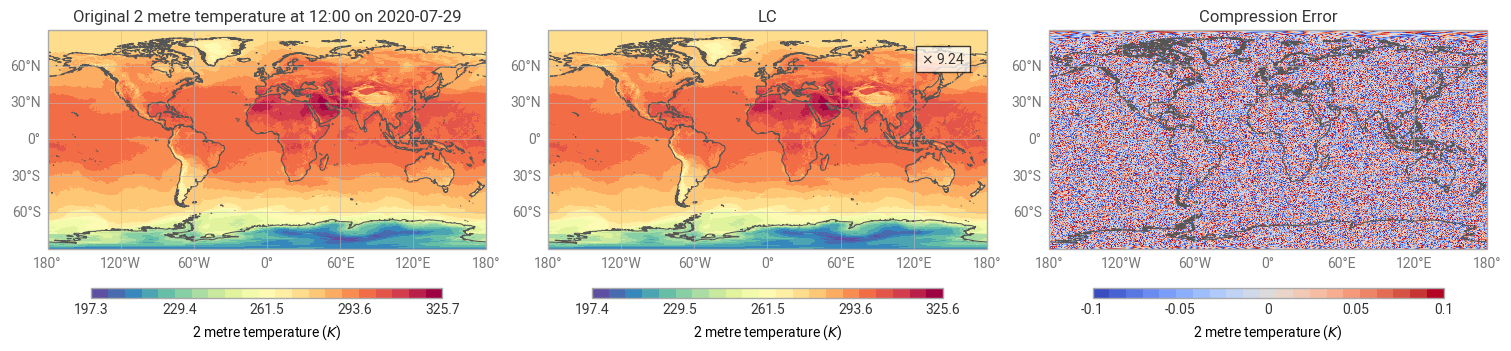

[pyodide]: Memory usage has grown to 1006.6MiB (from 464.4MiB) for this notebook
[pyodide]: Loaded 2 new dynamic libraries (230 total for this notebook)


In [15]:
# plot a comparison figure
fig = earthkit.plots.Figure(
    figsize=(15, 4),
    rows=1,
    columns=3,
)

quickplot(da, fig.add_map(0, 0), title="Original {default_title}")
quickplot(da_dec, fig.add_map(0, 1), title="LC", cr=da.nbytes / np.array(da_enc).nbytes)
quickplot(da_dec - da, fig.add_map(0, 2), error=True, title="Compression Error")

fig.show()